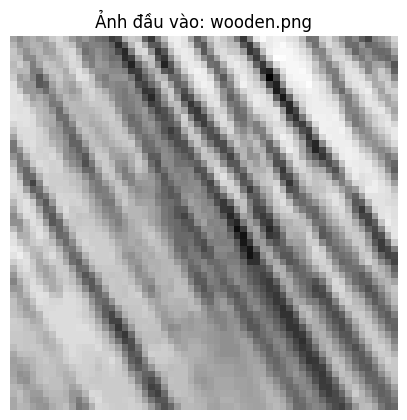

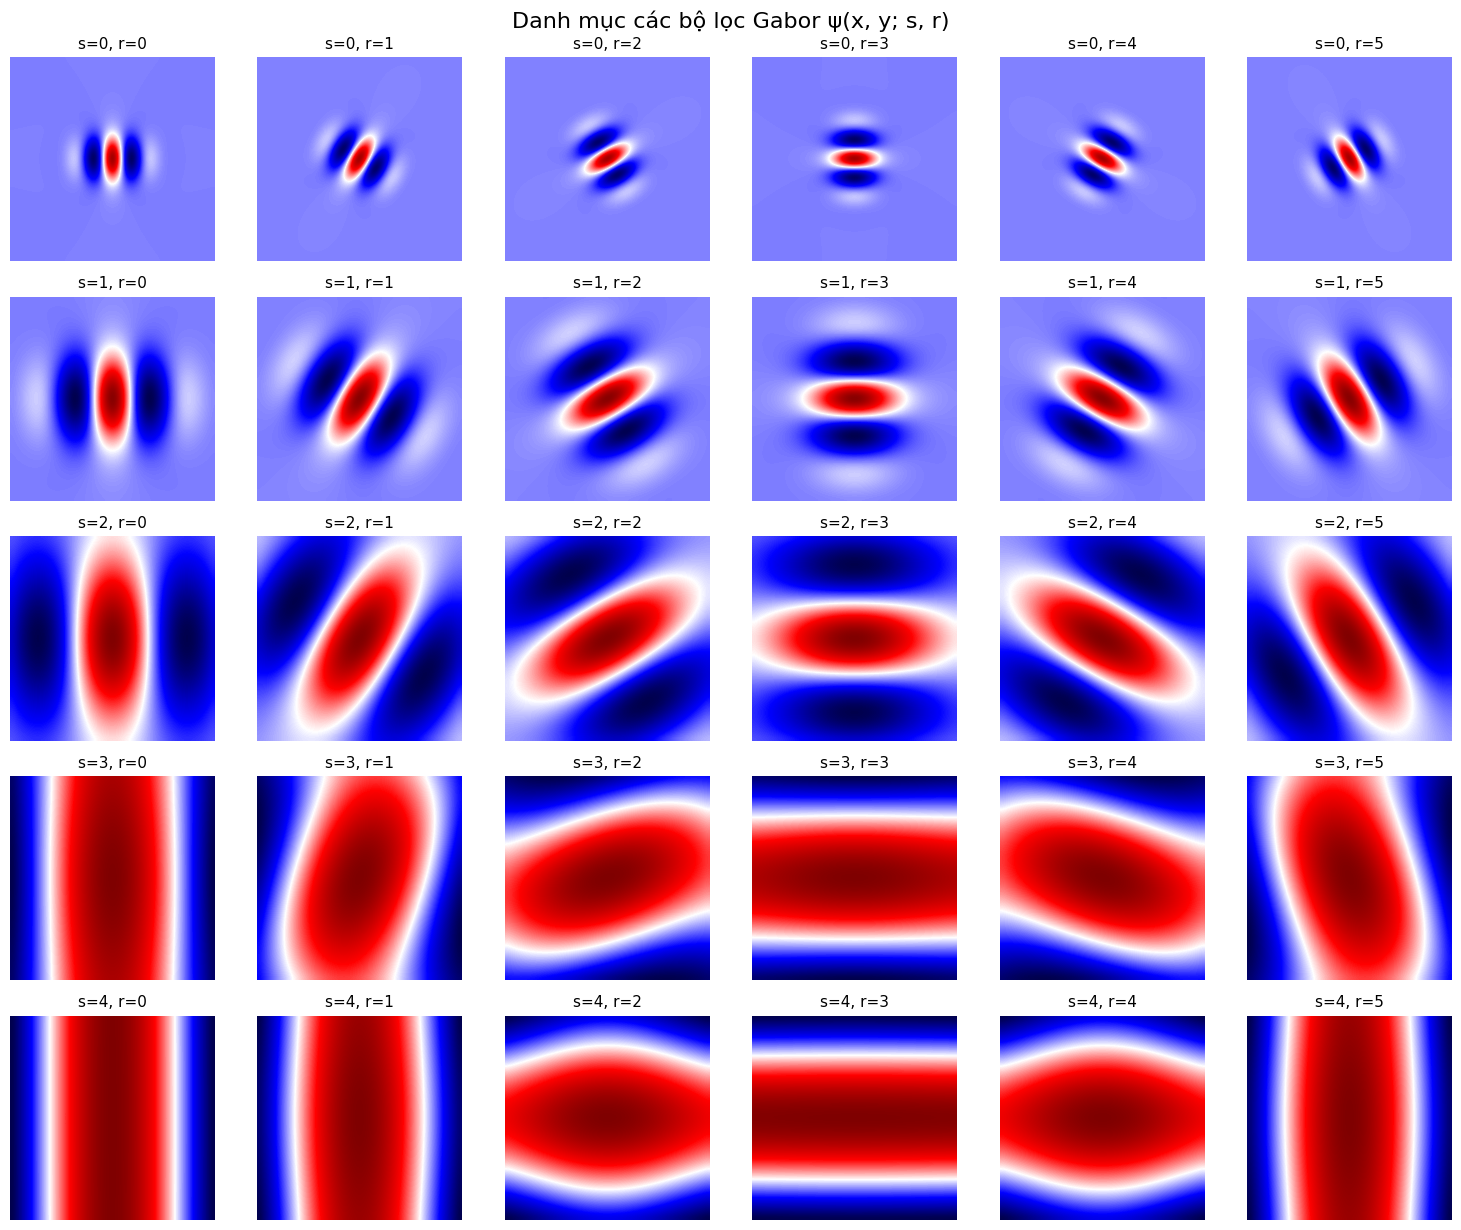

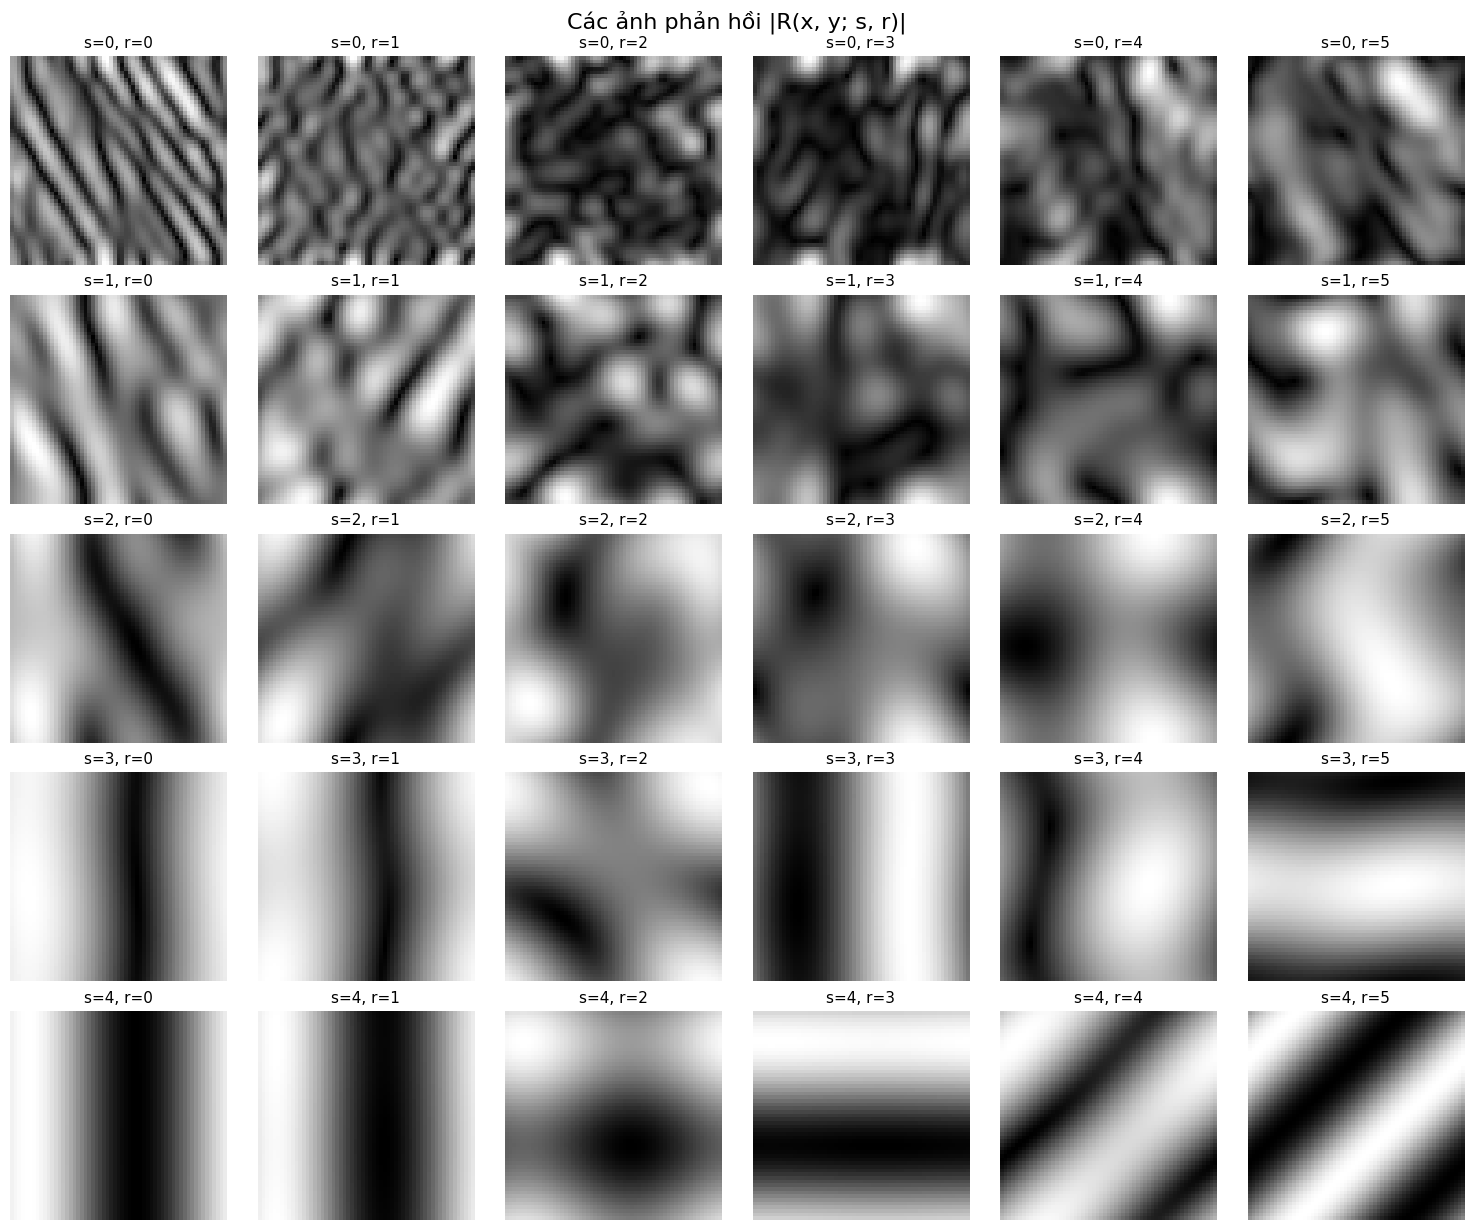

E_{s,r}:
[[1.60269493e-02 7.22536037e-03 2.84366774e-03 4.01292749e-03
  1.21557303e-02 1.90516726e-02]
 [1.43343134e-02 7.19522074e-03 2.61294230e-03 4.05722089e-03
  7.52730945e-03 1.00636027e-02]
 [1.42427020e-02 7.36563994e-03 3.45666479e-03 4.23236749e-03
  1.15270776e-02 1.16145665e-02]
 [1.59379435e-02 7.99177337e-03 2.67069064e-03 5.02023363e-03
  3.28067086e-03 6.09354695e-03]
 [1.31795064e-02 6.58975318e-03 8.23720095e-04 2.58626197e-05
  1.96286750e-06 9.12775772e-06]]

sigma_{s,r}:
[[6.94081764e-03 2.52992010e-03 1.77520032e-03 2.82334021e-03
  6.59749805e-03 1.01316252e-02]
 [4.94533348e-03 2.46590933e-03 1.41609450e-03 2.28872273e-03
  4.13722101e-03 4.17546017e-03]
 [5.09352528e-03 3.37598722e-03 1.18645738e-03 1.95449335e-03
  2.97373862e-03 3.39008481e-03]
 [7.50382168e-03 3.76107940e-03 8.94480861e-04 5.41775046e-04
  1.54291779e-03 1.68343029e-03]
 [1.29067106e-05 6.45524394e-06 1.48720570e-06 2.49467278e-06
  7.81361385e-07 1.56154179e-07]]

F_Gabor:
[1.60269493e-02

In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: TRÍCH CHỌN ĐẶC TRƯNG KẾT CẤU BẰNG BỘ LỌC GABOR
# Chương/Mục liên quan: Chương 5 - Đặc trưng thủ công
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách xây dựng danh mục bộ lọc Gabor trên miền tần số.
# - Áp dụng các bộ lọc Gabor ở nhiều tỉ lệ và hướng khác nhau lên ảnh kết cấu.
# - Trích chọn vector đặc trưng Gabor từ trung bình và độ lệch chuẩn của các ảnh phản hồi.

# Sau khi chạy code, người học cần:
# 1. Quan sát được hình dạng của các bộ lọc Gabor ở nhiều tỉ lệ và hướng.
# 2. Quan sát được phản hồi của ảnh với từng bộ lọc Gabor.
# 3. Hiểu cách tạo vector đặc trưng F_Gabor từ các thống kê E_{s,r} và sigma_{s,r}.

# Input:
# - Dữ liệu đầu vào: ảnh wooden.png từ GitHub.
# - Kiểu dữ liệu: ảnh xám.

# Output:
# - Ảnh đầu vào.
# - Danh mục bộ lọc Gabor trong miền không gian.
# - Các ảnh phản hồi sau lọc.
# - Ma trận E_{s,r}, sigma_{s,r} và vector đặc trưng F_Gabor.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

image_url = "https://github.com/lthavnu/cv-book/raw/main/images/wooden.png"

# Chọn các giá trị scale và hướng theo MPEG-7 HDT
s_values = [0, 1, 2, 3, 4]
r_values = [0, 1, 2, 3, 4, 5]

def read_gitlab_image_gray(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    I = cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)
    return I

I_uint8 = read_gitlab_image_gray(image_url)
I = I_uint8.astype(np.float32) / 255.0

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(I, cmap="gray")
plt.title("Ảnh đầu vào: wooden.png")
plt.axis("off")
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

def create_frequency_grid(H, W):
    omega_x = np.fft.fftfreq(W) * 2 * np.pi
    omega_y = np.fft.fftfreq(H) * 2 * np.pi
    omega_x, omega_y = np.meshgrid(omega_x, omega_y)

    omega_x = np.fft.fftshift(omega_x)
    omega_y = np.fft.fftshift(omega_y)

    omega = np.sqrt(omega_x**2 + omega_y**2)
    theta = np.arctan2(omega_y, omega_x)

    return omega, theta

def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def create_gabor_filter_frequency_domain(H, W, s, r):
    omega, theta = create_frequency_grid(H, W)

    theta_r = r * np.pi / 6.0
    omega_s = (3.0 / 4.0) * (2.0 ** (-s))

    sigma_rho = ((np.sqrt(2.0) - 1.0) /
                 np.sqrt(2.0 * np.log(2.0))) * omega_s

    sigma_theta = np.pi / (6.0 * np.sqrt(2.0 * np.log(2.0)))

    dtheta = wrap_angle(theta - theta_r)

    # Công thức tạo bộ lọc Gabor trên miền tần số Ψ(ω, θ; s, r)
    Psi = np.exp(-((omega - omega_s) ** 2) / (2.0 * sigma_rho ** 2)) * \
          np.exp(-(dtheta ** 2) / (2.0 * sigma_theta ** 2))

    return Psi

def create_gabor_filter_bank(H, W, s_values=range(5), r_values=range(6)):
    filter_bank = []

    for s in s_values:
        for r in r_values:
            Psi = create_gabor_filter_frequency_domain(H, W, s, r)

            # Biến đổi Fourier ngược để thu được bộ lọc trong miền không gian
            psi = np.fft.ifft2(np.fft.ifftshift(Psi))

            filter_bank.append({
                "s": s,
                "r": r,
                "Psi": Psi,
                "psi": psi
            })

    return filter_bank

def visualize_filter_bank_spatial(filter_bank, s_values, r_values, crop_size=41):
    n_rows = len(s_values)
    n_cols = len(r_values)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows))

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array([[ax] for ax in axes])

    s_to_row = {s: i for i, s in enumerate(s_values)}
    r_to_col = {r: j for j, r in enumerate(r_values)}

    for filt in filter_bank:
        s = filt["s"]
        r = filt["r"]
        psi = filt["psi"]

        psi_real = np.real(np.fft.fftshift(psi))

        H, W = psi_real.shape
        cy, cx = H // 2, W // 2
        h = crop_size // 2

        patch = psi_real[cy-h:cy+h+1, cx-h:cx+h+1]

        # Chuẩn hóa từng bộ lọc để hiển thị rõ
        patch_show = (patch - patch.min()) / (patch.max() - patch.min() + 1e-8)

        row = s_to_row[s]
        col = r_to_col[r]
        ax = axes[row, col]

        ax.imshow(
            patch_show,
            cmap="seismic",
            interpolation="bicubic"
        )
        ax.set_title(f"s={s}, r={r}", fontsize=11)
        ax.axis("off")

    fig.suptitle("Danh mục các bộ lọc Gabor ψ(x, y; s, r)", fontsize=16)
    plt.tight_layout()
    plt.show()

def apply_gabor_filter_bank(I, filter_bank):
    F_I = np.fft.fft2(I)

    responses = []
    E_list = []
    sigma_list = []

    for filt in filter_bank:
        s = filt["s"]
        r = filt["r"]
        psi = filt["psi"]

        # Tích chập trong miền Fourier: R(x, y; s, r) = ψ(x, y; s, r) * I(x, y)
        R = np.fft.ifft2(F_I * np.fft.fft2(psi))

        # Biên độ phản hồi
        A = np.abs(R)

        # Tính trung bình và độ lệch chuẩn của ảnh phản hồi
        E_sr = np.mean(A)
        sigma_sr = np.sqrt(np.mean((A - E_sr) ** 2))

        responses.append({
            "s": s,
            "r": r,
            "A": A,
            "E_sr": E_sr,
            "sigma_sr": sigma_sr
        })

        E_list.append(E_sr)
        sigma_list.append(sigma_sr)

    # Vector đặc trưng Gabor gồm toàn bộ E_{s,r} và sigma_{s,r}
    F_Gabor = np.array(E_list + sigma_list, dtype=np.float64)

    return responses, F_Gabor

def visualize_responses(responses, s_values, r_values):
    n_rows = len(s_values)
    n_cols = len(r_values)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows))

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array([[ax] for ax in axes])

    s_to_row = {s: i for i, s in enumerate(s_values)}
    r_to_col = {r: j for j, r in enumerate(r_values)}

    for resp in responses:
        s = resp["s"]
        r = resp["r"]
        A = resp["A"]

        row = s_to_row[s]
        col = r_to_col[r]
        ax = axes[row, col]

        ax.imshow(A, cmap="gray")
        ax.set_title(f"s={s}, r={r}", fontsize=11)
        ax.axis("off")

    fig.suptitle("Các ảnh phản hồi |R(x, y; s, r)|", fontsize=16)
    plt.tight_layout()
    plt.show()

H, W = I.shape
filter_bank = create_gabor_filter_bank(H, W, s_values=s_values, r_values=r_values)

responses, F_Gabor = apply_gabor_filter_bank(I, filter_bank)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

visualize_filter_bank_spatial(
    filter_bank,
    s_values=s_values,
    r_values=r_values,
    crop_size=41
)

visualize_responses(
    responses,
    s_values=s_values,
    r_values=r_values
)

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

E_matrix = np.zeros((len(s_values), len(r_values)), dtype=np.float64)
sigma_matrix = np.zeros((len(s_values), len(r_values)), dtype=np.float64)

s_to_row = {s: i for i, s in enumerate(s_values)}
r_to_col = {r: j for j, r in enumerate(r_values)}

for resp in responses:
    s = resp["s"]
    r = resp["r"]
    row = s_to_row[s]
    col = r_to_col[r]
    E_matrix[row, col] = resp["E_sr"]
    sigma_matrix[row, col] = resp["sigma_sr"]

print("E_{s,r}:")
print(E_matrix)

print("\nsigma_{s,r}:")
print(sigma_matrix)

print("\nF_Gabor:")
print(F_Gabor)

print("\nKích thước F_Gabor =", F_Gabor.shape)

expected_length = 2 * len(s_values) * len(r_values)

print("\nKiểm tra số lượng bộ lọc =", len(filter_bank))
print("Số lượng bộ lọc kỳ vọng =", len(s_values) * len(r_values))

print("\nKiểm tra độ dài vector F_Gabor =", len(F_Gabor))
print("Độ dài kỳ vọng =", expected_length)

assert len(filter_bank) == len(s_values) * len(r_values)
assert len(F_Gabor) == expected_length
assert E_matrix.shape == (len(s_values), len(r_values))
assert sigma_matrix.shape == (len(s_values), len(r_values))

print("\nKết luận: Code chạy đúng về kích thước filter bank, ma trận thống kê và vector đặc trưng.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi s_values để quan sát ảnh hưởng của số mức tỉ lệ lên số lượng bộ lọc và vector đặc trưng.
# 2. Thay đổi r_values để quan sát ảnh hưởng của số hướng lọc lên ảnh phản hồi.
# 3. Thay đổi crop_size trong visualize_filter_bank_spatial để quan sát bộ lọc Gabor ở vùng không gian rộng hoặc hẹp hơn.